In [11]:
import pandas as pd
import sqlite3

In [6]:
df1_path = r"C:\Users\tonyw\Downloads\simplemaps_uscities_basicv1.78\uscities.csv" # us
df1 = pd.read_csv(df1_path)

df2_path = r"C:\Users\tonyw\Downloads\simplemaps_canadacities_basicv1.8\canadacities.csv" # canada
df2 = pd.read_csv(df2_path)

column_mapping = {
    'province_id': 'state_id',
    'province_name': 'state_name',
    'postal': 'zip'
}

df2_mapped = df2.rename(columns=column_mapping)


In [9]:
# Check if the column names are the same, and if not, align them
if not df1.columns.equals(df2_mapped.columns):
    # Add missing columns from df1 to df2
    missing_columns = df1.columns.difference(df2_mapped.columns)
    for column in missing_columns:
        df2_mapped[column] = None

    # Add missing columns from df2 to df1
    missing_columns = df2_mapped.columns.difference(df1.columns)
    for column in missing_columns:
        df1[column] = None

# Append df2 to df1
df1 = pd.concat([df1, df2_mapped], ignore_index=True)

In [12]:
# Create a connection to the SQLite database
conn = sqlite3.connect('ipg.sqlite')

# Insert df1 into the 'coordinates' table
df1.to_sql('coordinates', conn, if_exists='replace', index=False)

# Commit the changes and close the connection
conn.commit()
conn.close()


In [13]:
import pandas as pd
import sqlite3

# Connect to the SQLite database
conn = sqlite3.connect('ipg.sqlite')

# Read data from SQL tables into Pandas DataFrame
shipments_df = pd.read_sql_query('SELECT * FROM shipments', conn)
coordinates_df = pd.read_sql_query('SELECT * FROM coordinates', conn)

# Convert ship_to_city and state columns to lowercase for case-insensitive comparison
shipments_df['ship_to_city'] = shipments_df['ship_to_city'].str.lower()
shipments_df['state'] = shipments_df['state'].str.lower()
coordinates_df['city_ascii'] = coordinates_df['city_ascii'].str.lower()
coordinates_df['state_id'] = coordinates_df['state_id'].str.lower()

# Merge the DataFrames using case-insensitive comparison
merged_df = pd.merge(shipments_df, coordinates_df, 
                     left_on=['ship_to_city', 'state'], 
                     right_on=['city_ascii', 'state_id'], 
                     how='left')

# Select desired columns
result_df = merged_df[['bl_number', 'ship_to_city', 'state', 'ship_to_customer', 'lat', 'lng']]

# Print the result DataFrame
print(result_df)

     bl_number ship_to_city state                  ship_to_customer      lat  \
0      WZ1A912       irvine    ca                    MARUCHAN, INC.  33.6772   
1      WZ2A753      gardena    ca                      NISSIN FOODS  33.8943   
2      WZ3A004        chino    ca  WORLD CLASS DISTRIBUTION - CHINO  33.9836   
3      WZ3A004        chino    ca  WORLD CLASS DISTRIBUTION - CHINO  33.9836   
4      WZ3A060        lacey    wa      WORLD CLASS DISTRIBUTION -WA  47.0462   
...        ...          ...   ...                               ...      ...   
8002   2068803  white bluff    tn                   INTERSTATE PKG.  36.1005   
8003   2068803  white bluff    tn                   INTERSTATE PKG.  36.1005   
8004   2068803  white bluff    tn                   INTERSTATE PKG.  36.1005   
8005   2068805   cincinnati    oh                          CPG OHIO  39.1413   
8006   2068805   cincinnati    oh                          CPG OHIO  39.1413   

           lng  
0    -117.7738  
1    

Cluster 1: [(31.2336, -85.407)]
Cluster 2: [(34.4892, -93.0501)]
Cluster 3: [(36.6243, -119.6737)]
Cluster 4: [(38.5737, -121.2527)]
Cluster 5: [(34.274647, -119.229034)]
Cluster 6: [(34.0334, -117.8593)]
Cluster 7: [(39.8641, -104.843), (39.762, -104.8758), (40.469, -104.9198)]
Cluster 8: [(30.1901, -82.6471)]
Cluster 9: [(28.4773, -81.337)]
Cluster 10: [(27.8227, -82.3023)]
Cluster 11: [(34.1192, -83.9903), (33.6363, -84.464)]
Cluster 12: [(30.879, -84.205)]
Cluster 13: [(32.2062, -82.3215)]
Cluster 14: [(34.2662, -85.1863)]
Cluster 15: [(43.5844, -116.5638)]
Cluster 16: [(41.8445, -87.7593)]
Cluster 17: [(39.8337, -86.383)]
Cluster 18: [(38.1663, -85.6485)]
Cluster 19: [(42.3834, -83.1024)]
Cluster 20: [(43.1621, -86.2519)]
Cluster 21: [(44.0505, -91.6684)]
Cluster 22: [(32.3157, -90.2125)]
Cluster 23: [(34.961, -89.8469), (35.1087, -89.9663)]
Cluster 24: [(46.8651, -96.8292)]
Cluster 25: [(41.1816, -96.0664)]
Cluster 26: [(40.7967, -74.4772)]
Cluster 27: [(41.418, -81.6681)]
Cluste

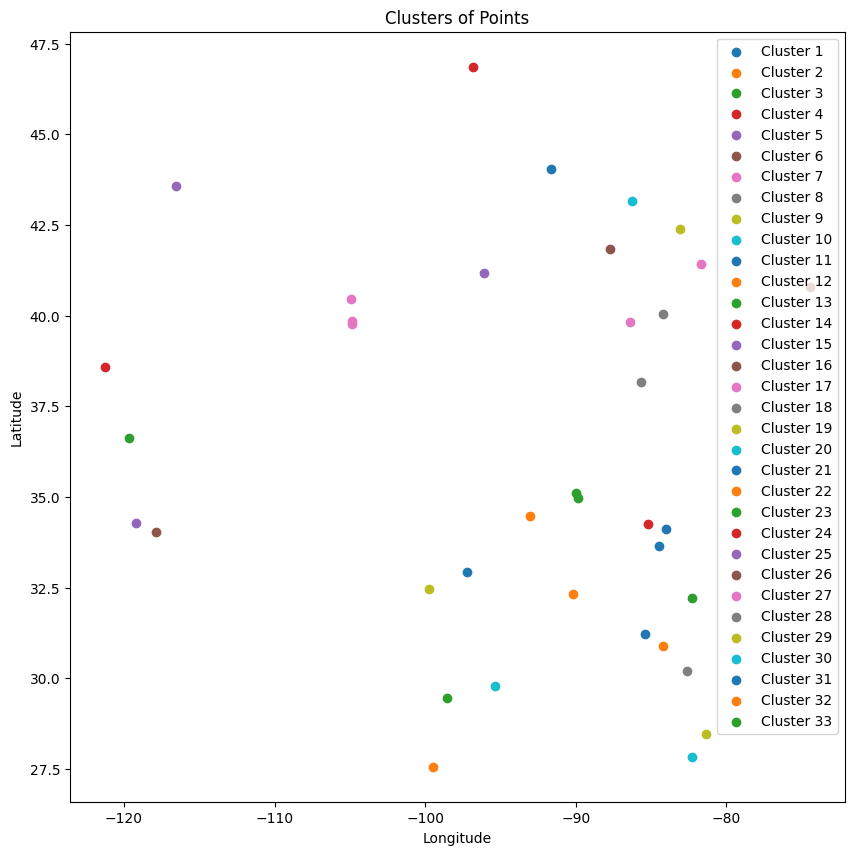

,Unnamed: 0,site,product_group,bl_number,ship_to_customer,ship_to_city,state,net_pick_weight,total_number_of_pallet,lat,lng,coordinates,cluster
0,0,AMJK,SW,W44A387,LINEAGE LOGISTICS LLC,DOTHAN,AL,3301,3,31.233600,-85.407000,"(31.2336, -85.407)",0
1,1,AMJK,SW,W43A800,SIGMA SUPPLY OF NORTH AMERICA,HOT SPRINGS,AR,17280,10,34.489200,-93.050100,"(34.4892, -93.0501)",1
2,2,AMJK,SW,W44A283,MID VALLEY PACKAGING & SUPPLY CO.,FOWLER,CA,6400,5,36.624300,-119.673700,"(36.6243, -119.6737)",2
3,3,AMJK,SW,W44A478,RENEW PACKAGING SOULTIONS (RIVER CITY),RANCHO CORDOVA,CA,43336,37,38.573700,-121.252700,"(38.5737, -121.2527)",3
4,4,AMJK,SW,W44A458,PEMKO MFG CO,VENTURA,CA,2560,2,34.274647,-119.229034,"(34.274647, -119.229034)",4
5,5,AMJK,SW,W43B191,KELLY SPICERS,WALNUT,CA,3992,4,34.033400,-117.859300,"(34.0334, -117.8593)",5
7,7,AMJK,SW,W44A425,NEW HAVEN MOVING EQUIPMENT OF DENVER,DENVER,CO,12237,8,39.762000,-104.875800,"(39.762, -104.8758)",6
8,8,AMJK,SW,W44A359,LINEAGE LOGISTICS LLC,WINDSOR,CO,6820,8,40.469000,-104.919800,"(40.469, -104.9198)",6
6,6,AMJK,SW,W43C090,NEWAY PACKAGING,COMMERCE CITY,CO,6779,5,39.864100,-104.843000,"(39.8641, -104.843)",6
9,9,AMJK,SW,W44A351,HUB INDUSTRIAL SUPPLY,LAKE CITY,FL,8295,5,30.190100,-82.647100,"(30.1901, -82.6471)",7


In [11]:
import pandas as pd
from sklearn.cluster import DBSCAN
from geopy.distance import geodesic
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\TonyW\Downloads\2024-04-12T16-54_export.csv")
# data = {
#     'lat': [46.67456497473562, 40.7128, 34.0522,   37.7749, 47.6062, 34.23665353995374, 46.22912475893864, 45.85682099975919, 40.71784300085435, 43.11890374783543, 43.089991997478315],
#     'lng': [-122.65187649565887, -74.0060, -118.2437,    -122.4194, -122.3321,  -117.8707485081258, -122.88164287776588, -122.71493265741698, -74.05098331520506, -76.1502548312469, -87.9845301381357]
# }

# df = pd.DataFrame(data)

# Assuming df is your DataFrame and it has columns 'lat' and 'lng'
df['coordinates'] = list(zip(df.lat, df.lng))

# Convert latitude and longitude to radians
coords = np.radians(df[['lat', 'lng']].values)

# Use DBSCAN to cluster the points based on distance
kms_per_radian = 6371.0088
epsilon = 95 / kms_per_radian  # 95 miles converted to radians
db = DBSCAN(eps=epsilon, min_samples=1, algorithm='ball_tree', metric='haversine').fit(coords)
cluster_labels = db.labels_

# Add the cluster labels to the DataFrame
df['cluster'] = cluster_labels

# Post-process the clusters to split any clusters that have more than 3 points
clusters = df.groupby('cluster')['coordinates'].apply(list).to_dict()
new_clusters = []
for cluster in clusters.values():
    while len(cluster) > 3:
        new_clusters.append(cluster[:3])
        cluster = cluster[3:]
    new_clusters.append(cluster)

# Now, 'new_clusters' is a list of clusters with each cluster containing at most 3 points
# Print the clusters
for i, cluster in enumerate(new_clusters):
    print(f"Cluster {i+1}: {cluster}")






# Create a new figure
plt.figure(figsize=(10, 10))

# Plot each cluster
for i, cluster in enumerate(new_clusters):
    # Extract the latitudes and longitudes for this cluster
    lats, lngs = zip(*cluster)
    
    # Plot the points for this cluster
    plt.scatter(lngs, lats, label=f'Cluster {i+1}')

# Add a legend
plt.legend()

# Add labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Clusters of Points')

# Show the plot
plt.show()

df[['bl_number', 'ship_to_customer', 'ship_to_city', 'state', 'cluster']]
sorted_df = df.sort_values(by='cluster')
sorted_df